In [1]:
import numpy as np
import matplotlib.pyplot as plt
from define_data_and_variables import get_data, get_hmc_config
import arviz as az

In [2]:
data = get_data()
config, config_str = get_hmc_config()
find_min_config,find_min_config_str = get_hmc_config(True)
colors = plt.cm.viridis(np.linspace(0, 1, config["nch"]))

In [3]:
samples = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/output/age_depth_unf_tb/samples_{config_str}.npy")
energy_values = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/output/age_depth_unf_tb/energy_{config_str}.npy")
bias_values = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/output/age_depth_unf_tb/bias_{config_str}.npy")
resampled_samples = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/output/age_depth_unf_tb/resamp_{config_str}.npy")

In [4]:
starting_points = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/output/age_depth_unified_cap/samples_min_N50_H100_dc2.00_a1.50_b0.21_nch4_nlsp1000_mi100000_dt0.00_gl0.00.npy")
starting_energies = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/output/age_depth_unified_cap/Emin_N50_H100_dc2.00_a1.50_b0.21_nch4_nlsp1000_mi100000_dt0.00_gl0.00.npy")

In [5]:
# print(starting_points)
print(np.sort(starting_energies))

[ 191.86443436  199.913819    216.38889066  219.65079741  224.15929214
  229.76237147  232.42318674  232.8907319   235.35587667  237.08213294
  237.46288869  248.1429085   252.3687299   253.59446466  253.64028511
  254.93619112  255.81158461  256.31088897  257.22311056  262.07416507
  263.12350878  263.58222361  263.64081212  266.01342754  266.78856671
  267.32057057  267.82437351  268.13712183  268.28133609  269.8513435
  270.21504746  270.70315953  272.09496487  274.30249932  276.42600126
  276.67946885  279.61842268  279.88607729  280.16185598  280.32787416
  281.0680305   281.44123283  281.53956606  282.3640655   284.52826223
  284.74541558  285.34831041  285.67955972  285.93824724  288.78557318
  290.94321721  291.25461907  291.33916431  292.38778775  292.72449786
  292.93803397  295.58014764  296.24320582  299.27303959  299.51970605
  299.84580186  300.15467556  300.6504867   300.80192407  300.90698301
  301.91745039  303.05646262  304.50257652  305.47136129  306.12963748
  306.4

In [6]:
print(np.shape(resampled_samples))
print(np.shape(samples))

(5, 99000, 50)
(5, 100000, 50)


In [7]:
def expected_ages(N, delta_c, cs, theta, num_depths, depths, sed_rates, indices):
    cumulative_sum_vec = [0.0] * (N + 1)
    
    # Build cumulative sum vector
    for i in range(1, N + 1):
        cumulative_sum_vec[i] = cumulative_sum_vec[i - 1] + sed_rates[i - 1] * delta_c
    
    ages_out = [0.0] * num_depths
    
    # Compute ages
    for i in range(num_depths):
        index = indices[i]
        cumulative_sum = cumulative_sum_vec[index]
        cumulative_sum += sed_rates[index] * (depths[i] - cs[index])
        ages_out[i] = theta - cumulative_sum
    
    return ages_out


def get_index(N, cs, c14_depths, depth_index):
    low, high = 0, N - 1
    target = c14_depths[depth_index]
    
    while low <= high:
        mid = (low + high) // 2
        if cs[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    
    return low - 1 if low > 0 else 0

In [8]:
print(energy_values)

[[199.09356283 203.21667878 210.3721628  ... 122.45792287 127.50074966
  121.44549149]
 [207.14245036 207.14245036 209.46319427 ... 181.68220906 185.12876964
  188.23975495]
 [221.91531879 229.41067386 237.84569211 ... 184.43244601 181.6669928
  186.83115757]
 [228.20047436 233.19106128 230.60084063 ... 173.41531402 174.80297581
  174.56541636]
 [234.55295896 237.66030078 245.35951624 ... 126.87185736 117.569373
  113.95397   ]]


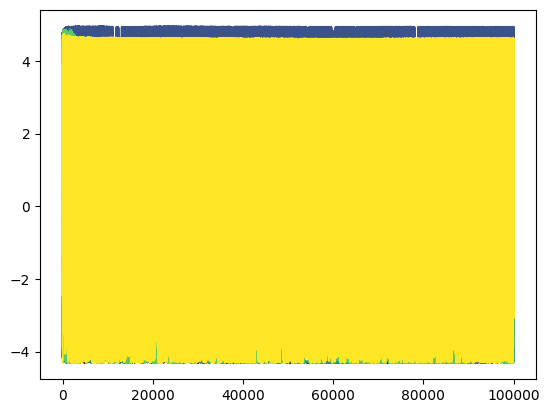

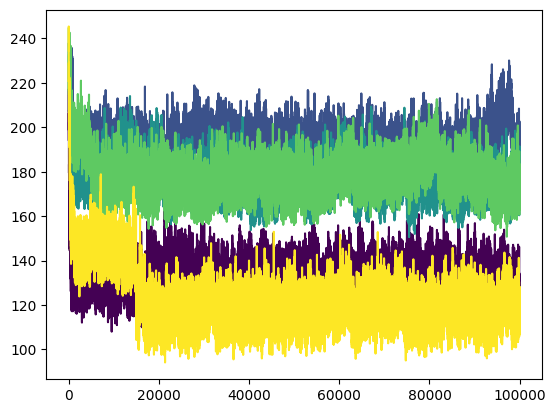

In [9]:
plt.figure()
for i in range(config["nch"]):
    plt.plot(bias_values[i,:], color = colors[i])
plt.show()

plt.figure()
for i in range(config["nch"]):
    plt.plot(energy_values[i,:], color = colors[i])
plt.show()


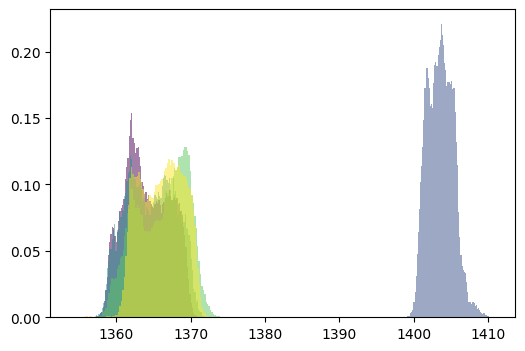

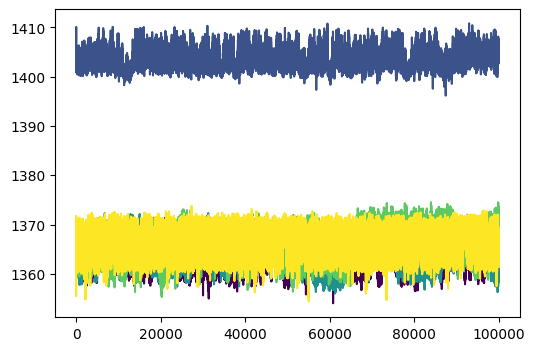

In [10]:
CV_values = data["theta"] - config["dc"] * np.sum(samples[:, :, :config["pidx"]], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.plot(CV_values[i, :], color = colors[i], label = f"chain {i}")
plt.show()

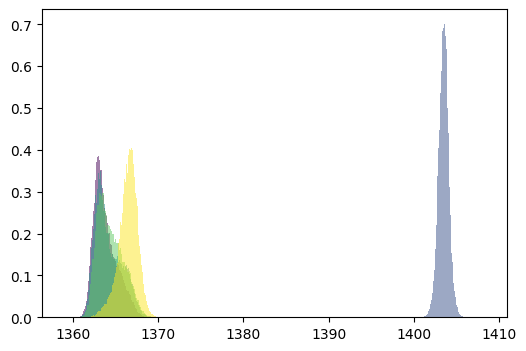

In [11]:
CV_values = data["theta"] - config["dc"] * np.sum(resampled_samples[:, :, :config["pidx"]], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.show()

In [12]:
resampled_samples = resampled_samples[:,::100,:]

In [13]:
print(np.max(bias_values))

4.950449111310201


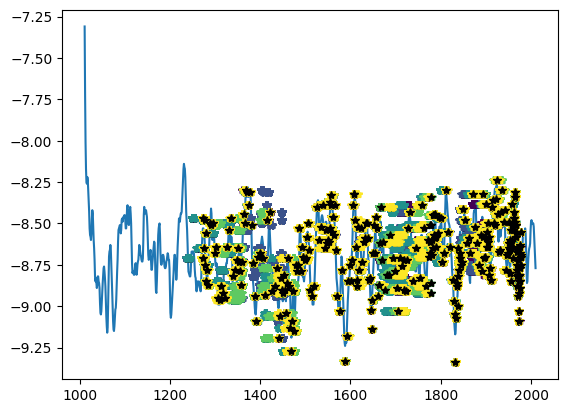

In [14]:
indices = []
for i in range(len(data["d18O_depths"])):
    index = get_index(config["N"], config["cs"], data["d18O_depths"], i)
    indices.append(index)

plt.figure()
plt.plot(data["d18O_reference_times"], data["d18O_reference"])
for i in range(config["nch"]):
    variables = resampled_samples[i,:,:]
    for j in range(len(variables)):
        d18O_ages = expected_ages(config["N"], config["dc"], config["cs"], data["theta"], len(data["d18O_depths"]), data["d18O_depths"], variables[j,:], indices)
        plt.plot(d18O_ages, data["d18O"], '*', color = colors[i])

plt.plot(data["true_ages_D18O"], data["d18O"], '*', color = "k")
plt.show()

In [15]:
# Print R_hat and N_eff using arviz
idata = az.convert_to_inference_data(resampled_samples)
summary = az.summary(idata, round_to=2)
print(summary)

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x[0]    2.78   0.23    2.35     3.20       0.00     0.00   4772.79   4503.79   
x[1]    4.67   0.54    3.74     5.71       0.03     0.01    301.46    683.08   
x[2]    5.51   1.19    4.15     7.33       0.19     0.31    124.21     31.56   
x[3]    6.59   1.49    3.83     9.36       0.22     0.36    167.77     39.01   
x[4]    6.76   1.13    4.97     9.05       0.02     0.02   4146.37   4575.26   
x[5]    4.58   1.03    2.75     6.49       0.01     0.02   4831.37   4665.11   
x[6]    4.62   1.64    1.97     7.07       0.03     0.22   4920.64    566.63   
x[7]    4.24   3.63    0.05    10.69       1.29     1.03      9.93     25.86   
x[8]    4.88   3.32    0.25    10.92       1.12     0.57     11.67     33.35   
x[9]    5.13   3.74    0.03    12.31       1.44     0.81      7.48     25.77   
x[10]   9.12   4.76    0.62    17.94       1.88     1.18      8.22     25.54   
x[11]   6.95   4.66    1.19    14.84    

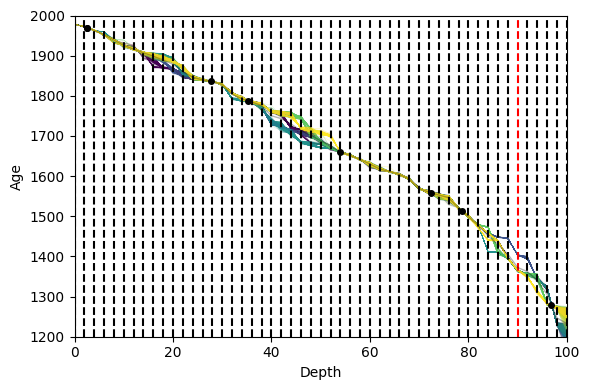

In [16]:
cumulative_sums = np.cumsum(resampled_samples[:, :,:], axis=2) * config["dc"]
zeros = np.zeros((*resampled_samples[:,:,:].shape[:2], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

model_ages = data["theta"] - age_offsets

mean_model_age = model_ages.mean(axis=(0, 1))

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(resampled_samples[0,:,0])
for i in range(config["nch"]):
    for j in range(num_samples):
        ax.plot(
            config["cs"],
            model_ages[i, j, :],
            color=colors[i],
            alpha=0.3,
            linewidth=0.1,
        )
for i, c in enumerate(config["cs"]):
    if i != config["pidx"]:
        ax.axvline(x=c, color='k', linestyle='--')
    else:
        ax.axvline(x=c, color='r', linestyle='--')

ax.set_xlim(0, np.max(config["cs"]))
ax.set_ylim(1200, 2000)
plt.plot(config["cs"], mean_model_age, color="black", alpha=0.3, linewidth=1)
plt.plot(data["c14_depths"], np.squeeze(data["c14_ages"]), "ko", markersize=4)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.show()